# Unit Test Notebook: Load And Show All Image Cases

This notebook reads the filenames listed in `list_of_test_data.md`, loads each image with the new `data_io.image` package, prints basic geometry/orientation information, and displays the central sagittal, coronal, and axial slices.


In [1]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "list_of_test_data.md").exists():
    NOTEBOOK_DIR = Path("/homebase/code_sync/myMedIADIRLab/data_io/unittest_image")

REPO_ROOT = NOTEBOOK_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_io.image import read_nifti, read_sitk, show_three_views
from data_io.image.image_orientLPS import get_axis_codes_from_affine

LIST_PATH = NOTEBOOK_DIR / "list_of_test_data.md"
SUPPORTED_SUFFIXES = (
    ".nii",
    ".nii.gz",
    ".mha",
    ".mhd",
    ".nrrd",
)


def parse_test_case_paths(list_path: Path) -> list[Path]:
    """Parse test image filenames from the markdown list file.

    Parameters
    ----------
    list_path : Path
        Markdown file that contains one filename per test case entry.

    Returns
    -------
    list[Path]
        Resolved absolute paths to the listed image files.
    """

    names: list[str] = []
    for raw_line in list_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith("What about"):
            continue
        if line.endswith(SUPPORTED_SUFFIXES):
            names.append(line)
    paths = [list_path.parent / name for name in names]
    return paths


def load_image_any(path: Path):
    """Load one image file using the appropriate backend helper.

    Parameters
    ----------
    path : Path
        Path to a supported image file.

    Returns
    -------
    object
        Canonical `MedicalImage` object returned by the image IO package.
    """

    path_str = str(path)
    if path_str.endswith((".nii", ".nii.gz")):
        return read_nifti(path)
    if path_str.endswith((".mha", ".mhd", ".nrrd")):
        return read_sitk(path)
    raise ValueError(f"Unsupported image file suffix: {path}")


TEST_CASE_PATHS = parse_test_case_paths(LIST_PATH)
print("Notebook directory:", NOTEBOOK_DIR)
print("List file:", LIST_PATH)
print("Discovered test cases:")
for case_path in TEST_CASE_PATHS:
    print("  ", case_path.name, "| exists=", case_path.exists())


Notebook directory: /homebase/code_sync/myMedIADIRLab/data_io/unittest_image
List file: /homebase/code_sync/myMedIADIRLab/data_io/unittest_image/list_of_test_data.md
Discovered test cases:
   mni_icbm152_2009c_t1_1mm_img.nii.gz | exists= True
   HN_RRT_Jess_tp1_ct.nii.gz | exists= True
   OASIS_ORG_0001_orig.nii.gz | exists= True
   mni_icbm152_2009c_t1_1mm_img_rotated.nii.gz | exists= True
   HN_RRT_Jess_tp1_ct_rotated.nii.gz | exists= True
   OASIS_ORG_0001_orig_rotated.nii.gz | exists= True


Case: mni_icbm152_2009c_t1_1mm_img.nii.gz
Native shape: (192, 224, 192)
Native axcodes (NIfTI RAS labels): ('L', 'P', 'S')
Native spacing (mm): [1. 1. 1.]
Canonical shape: (192, 224, 192)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [1. 1. 1.]


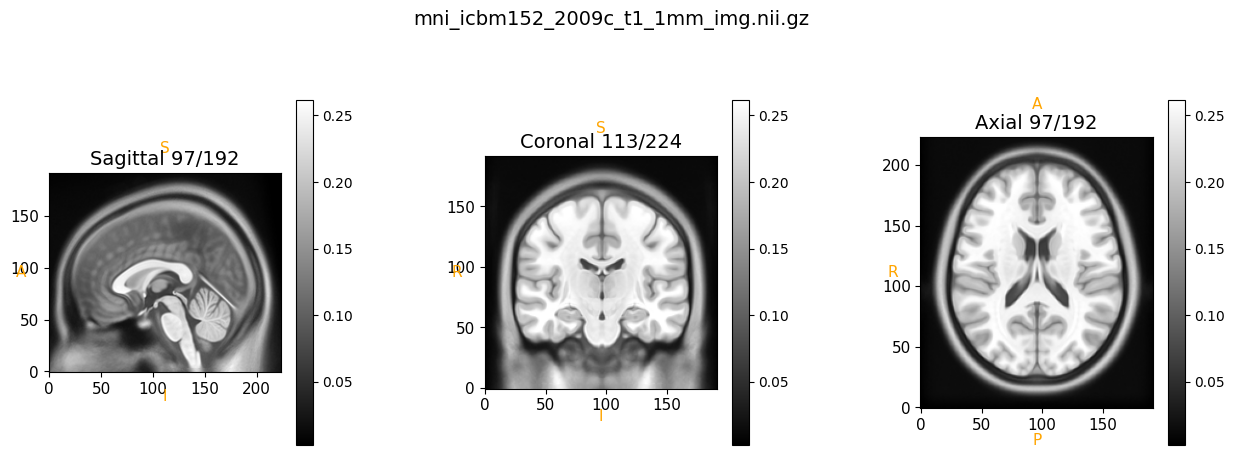

Case: HN_RRT_Jess_tp1_ct.nii.gz
Native shape: (512, 512, 129)
Native axcodes (NIfTI RAS labels): ('L', 'P', 'S')
Native spacing (mm): [0.9765625 0.9765625 3.       ]
Canonical shape: (512, 512, 129)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [0.9765625 0.9765625 3.       ]


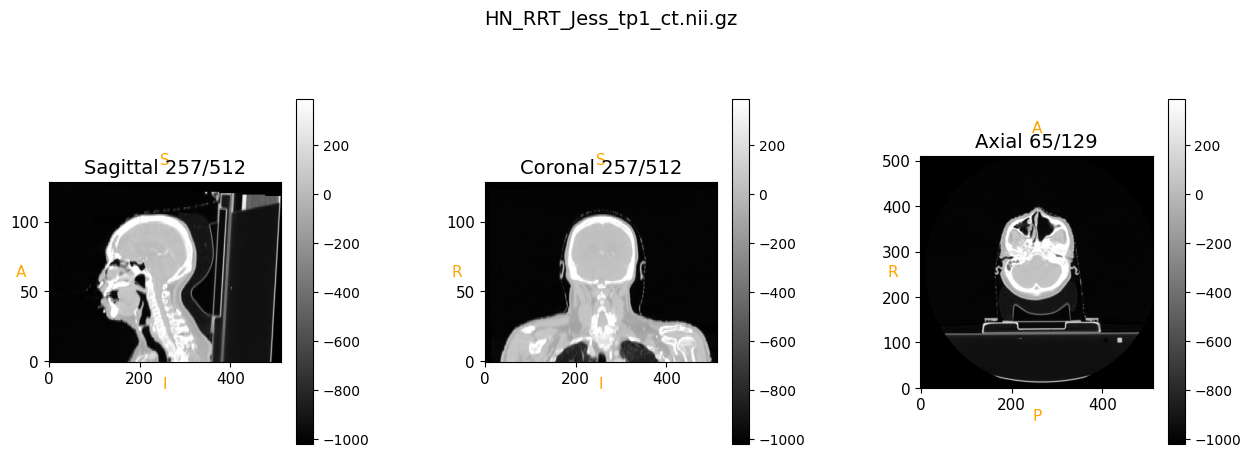

Case: OASIS_ORG_0001_orig.nii.gz
Native shape: (256, 256, 256)
Native axcodes (NIfTI RAS labels): ('L', 'I', 'A')
Native spacing (mm): [1. 1. 1.]
Canonical shape: (256, 256, 256)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [1. 1. 1.]


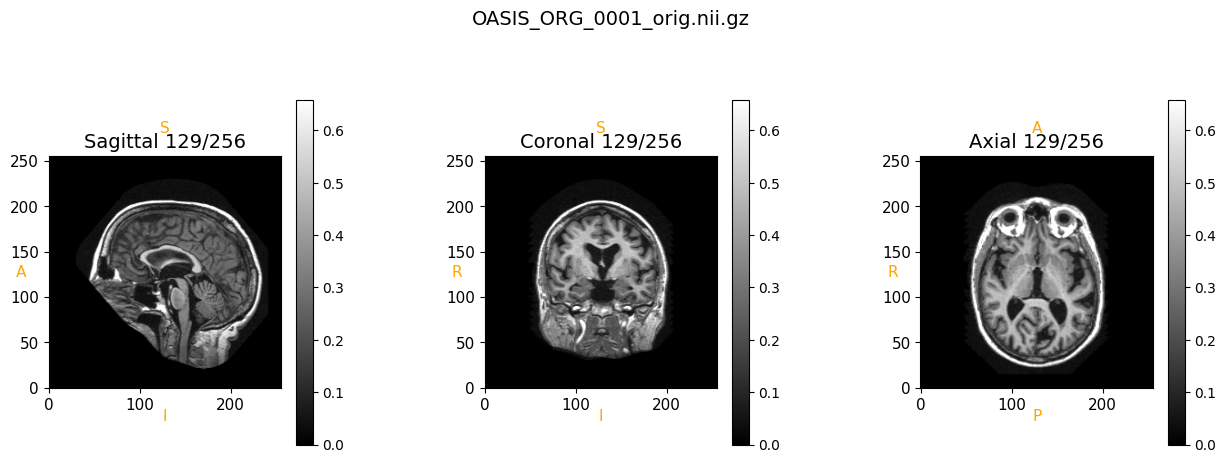

Case: mni_icbm152_2009c_t1_1mm_img_rotated.nii.gz
Native shape: (192, 224, 192)
Native axcodes (NIfTI RAS labels): ('L', 'P', 'S')
Native spacing (mm): [1.         1.         1.00000002]
Canonical shape: (192, 224, 192)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [1.         1.         1.00000002]


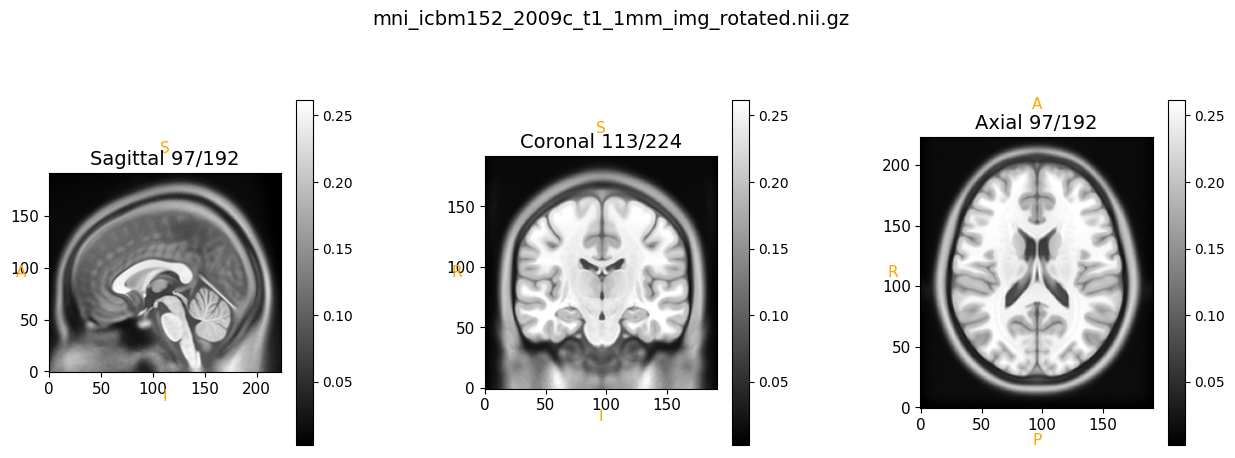

Case: HN_RRT_Jess_tp1_ct_rotated.nii.gz
Native shape: (512, 512, 129)
Native axcodes (NIfTI RAS labels): ('L', 'P', 'S')
Native spacing (mm): [0.9765625  0.97656251 2.99999991]
Canonical shape: (512, 512, 129)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [0.9765625  0.97656251 2.99999991]


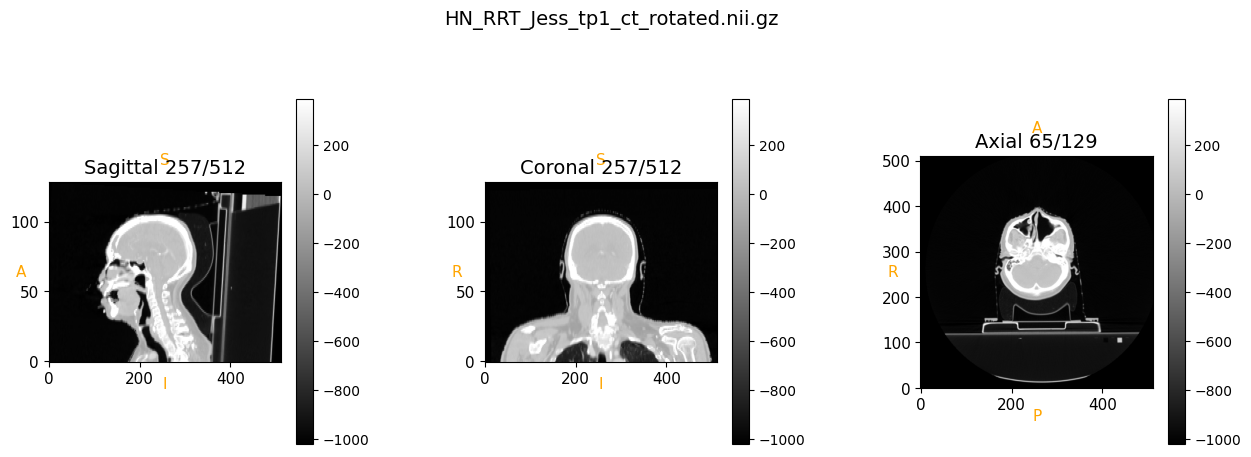

Case: OASIS_ORG_0001_orig_rotated.nii.gz
Native shape: (256, 256, 256)
Native axcodes (NIfTI RAS labels): ('L', 'I', 'A')
Native spacing (mm): [0.99999998 1.         1.        ]
Canonical shape: (256, 256, 256)
Canonical spatial_ndim: 3
Canonical LPS axcodes: ('L', 'P', 'S')
Canonical spacing (mm): [0.99999998 1.         1.        ]


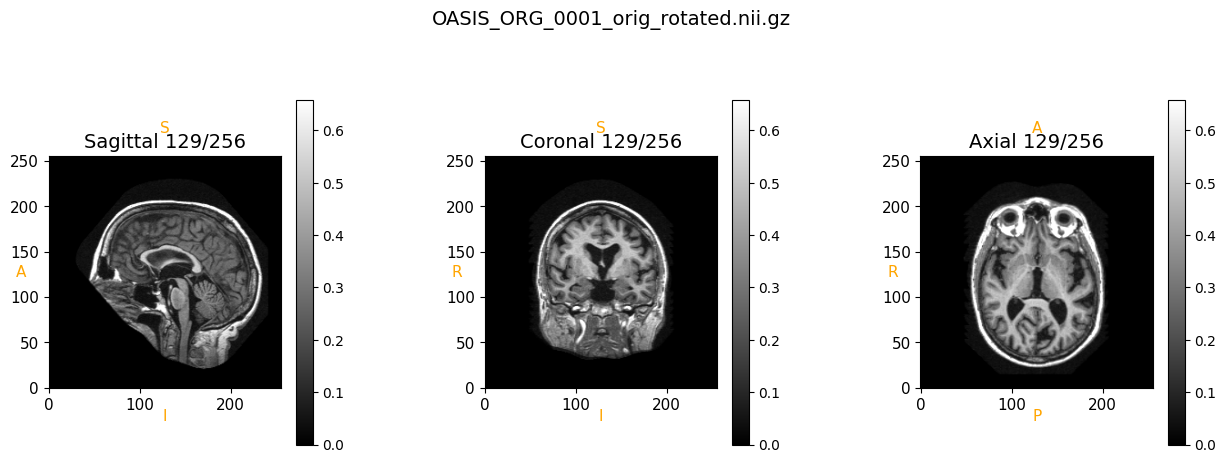

In [2]:
missing_paths = [path for path in TEST_CASE_PATHS if not path.exists()]
if missing_paths:
    missing_str = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(f"The following listed test images were not found:\n{missing_str}")

for case_path in TEST_CASE_PATHS:
    print("=" * 100)
    print(f"Case: {case_path.name}")

    native_nib = nib.load(str(case_path)) if str(case_path).endswith((".nii", ".nii.gz")) else None
    if native_nib is not None:
        print("Native shape:", native_nib.shape)
        print("Native axcodes (NIfTI RAS labels):", nib.orientations.aff2axcodes(native_nib.affine))
        print("Native spacing (mm):", nib.affines.voxel_sizes(native_nib.affine))

    image = load_image_any(case_path)
    print("Canonical shape:", image.shape)
    print("Canonical spatial_ndim:", image.spatial_ndim)
    print("Canonical LPS axcodes:", get_axis_codes_from_affine(image.affine_lps, image.spatial_ndim))
    print("Canonical spacing (mm):", image.spacing)

    fig, axes = show_three_views(
        image,
        figsize=(15.0, 5.0),
        cmap="gray",
        vmin_percentile=1.0,
        vmax_percentile=99.0,
        colorbar=True,
        title=case_path.name,
        title_fontsize=14.0,
        label_fontsize=11.0,
        show_orientation_labels=True,
    )
    plt.show()
